# Open Notebook & Additional Resources

<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/hands-on-multimodal-AI/blob/main/hands-on/DEMO_session_02_GLM_4.6_Flash.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://www.oreilly.com/library/view/transformers-the-definitive/9781098167004/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="Transformers: The Definitive Guide"/>
</a>




# About this Notebook


This notebook shows how to use [GLM_4.6_Flash](https://huggingface.co/zai-org/GLM-4.6V-Flash) to inspect different types of images, charts, a normal image, and a architectural diagram.

What you can produce with this is not just “a caption”. It is a retrieval friendly, semantically dense, modality normalized text surrogate for an image.

For RAG, the retriever only sees vectors. If the original object is an image, you have two options:

1. embed the image directly with an image embedding model
2. embed a text representation of the image

In practice you often want both, but the text surrogate is the unlock because it makes the image searchable by abstract language queries, not just visual similarity.

The outputs show you three distinct wins:

- `cats_balls.jpeg`: A user query like “cozy craft scene with yarn and a sleeping kitten” will match immediately. Without the explanation chunk, you need cross modal image embeddings to land on it.

- ´tradeoff_sft.png`: The explanation gives you “what the chart is about” at the semantic level, while extracted_text gives you the exact strings that people search for: axis labels and method names. That split is ideal:

    * extracted_text is keyword accurate
    * explanation is concept accurate

- `SAM_audio.png`: This is the killer case. Diagrams are high value and high entropy. The explanation chunk becomes a mini doc that can be retrieved for “multimodal audio generation pipeline” or “SAM 2 visual prompt diffusion transformer target audio”. You are basically turning a diagram into a searchable technical paragraph.

<br>

---

<br>

### How you use it in multimodal RAG

A simple pattern that works well:

* store image embedding for image similarity
* store explanation text embedding for semantic retrieval
* store extracted_text embedding for exact label retrieval
* at query time, do a weighted fusion of the three retrieval results



# Imports

In [ ]:
import subprocess
from pathlib import Path
from IPython.display import Image as IPyImage, display, Markdown
import json
import re
from datetime import datetime, timezone
from typing import Dict, List, Optional, Tuple, Any

import torch
from PIL import Image
from transformers import AutoProcessor, Glm4vForConditionalGeneration


In [ ]:

_IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".webp", ".gif", ".bmp", ".tif", ".tiff"}

def download_files(out_dir=".", quiet=False, display_assets=True, **files):
    """
    Download multiple Google Drive files via gdown.

    Returns dict: filename -> Path or IPython Image.
    Automatically displays images in notebook.
    """

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    results = {}

    for filename, file_id in files.items():
        dest = out_dir / filename

        cmd = ["gdown", "--id", str(file_id), "-O", str(dest)]
        if quiet:
            cmd.insert(1, "-q")

        subprocess.run(cmd, check=True)

        if not dest.exists() or dest.stat().st_size == 0:
            raise RuntimeError(f"Download failed: {dest}")

        print(f"✓ Downloaded: {dest.name}")

        if dest.suffix.lower() in _IMAGE_EXTS:
            obj = IPyImage(filename=str(dest), width=400)
            results[filename] = obj
            if display_assets:
                display(obj)
        else:
            results[filename] = dest
            if display_assets:
                print(dest)

    return results

✓ Downloaded: cats_balls.jpeg


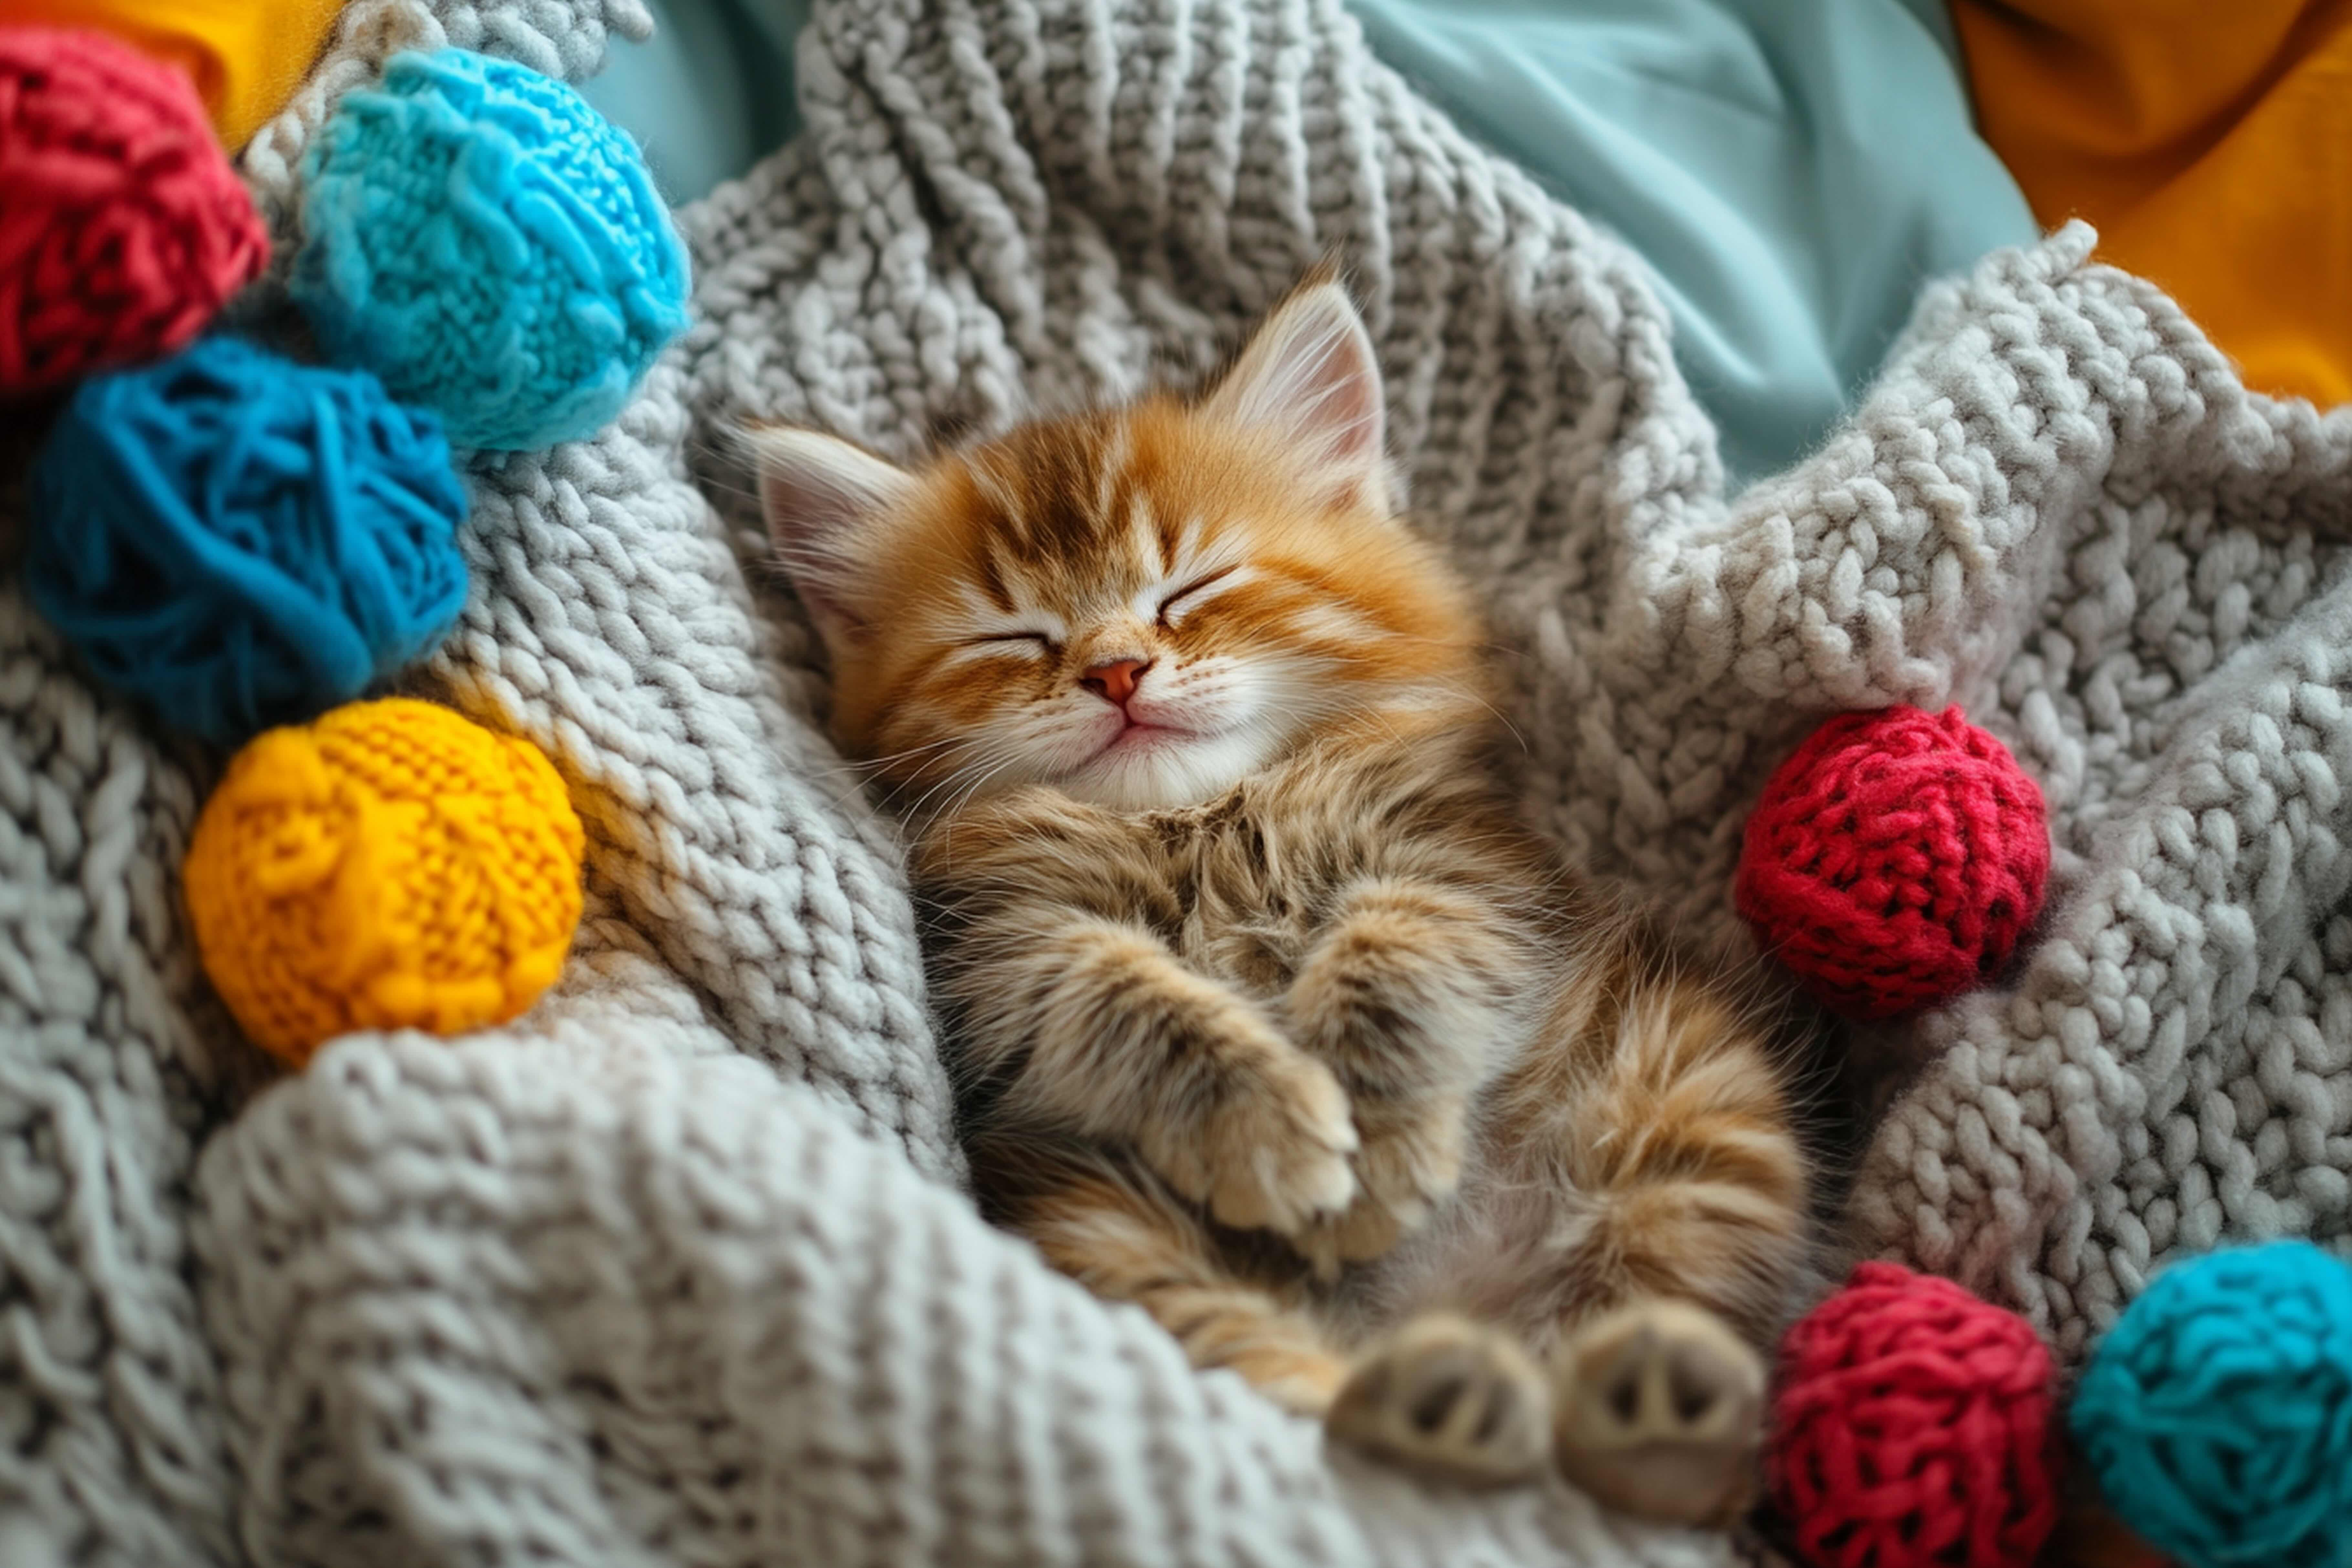

✓ Downloaded: tradeoff_sft.png


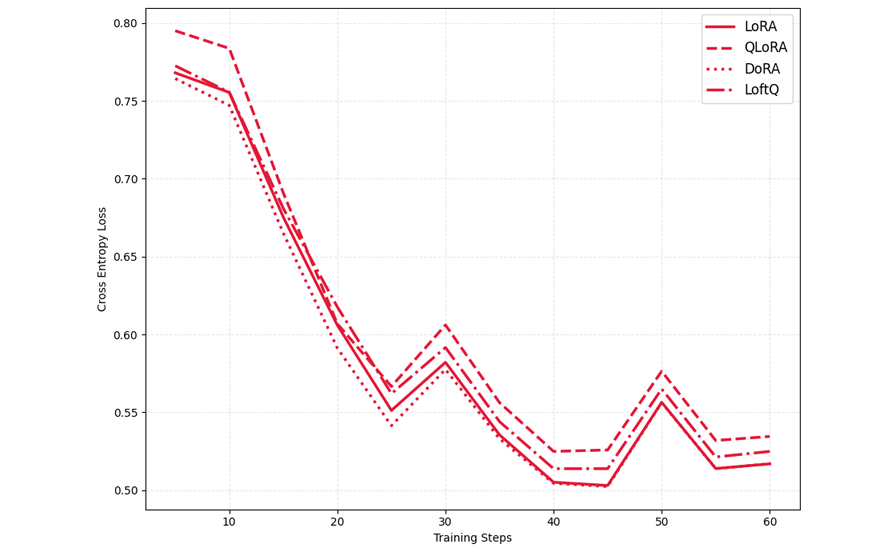

✓ Downloaded: SAM_audio.png


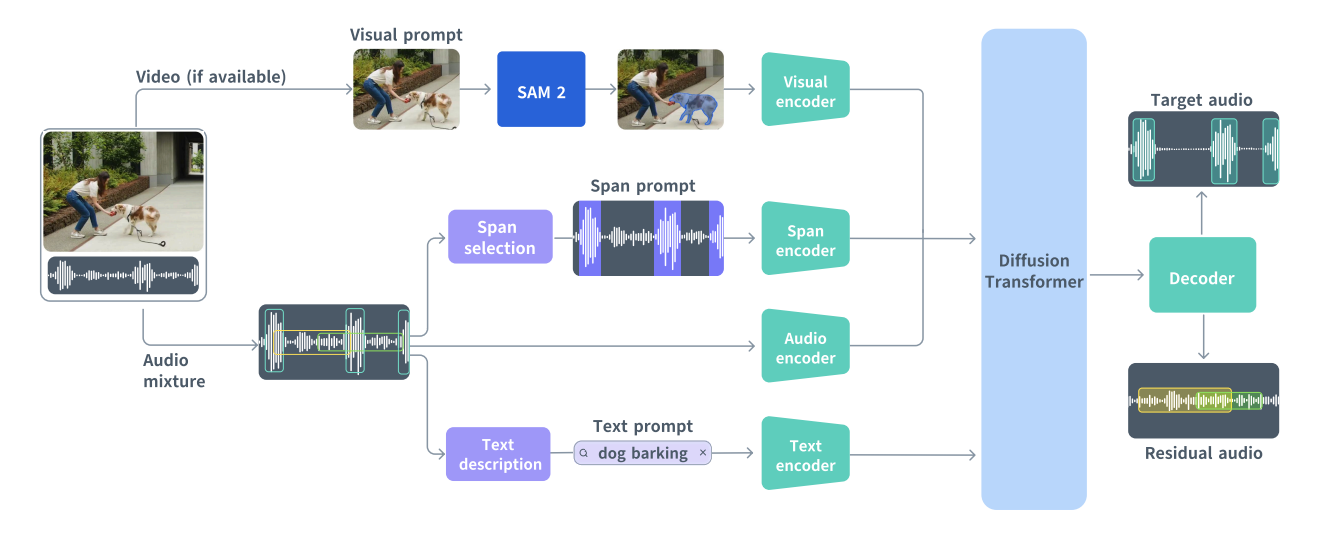

In [ ]:
files = {
    "cats_balls.jpeg": "1IKjM-BueAJw9xxXpCmQReWeWoKOzhv-j",
    "tradeoff_sft.png": "1jqw4PcaaC-KjkmUXkWmiPBqdFeLL1ZlI",
    "SAM_audio.png": "1FaiFdIUxV1a59UXMYHP_EXKAvXf2OGVj",
}


assets = download_files(out_dir="assets", **files)

# Model and Prompt

In [ ]:
MODEL_PATH = "zai-org/GLM-4.6V-Flash"

PROMPT_V1 = """
Return valid JSON only with keys:
visual_type, extracted_text, structured_facts, explanation, uncertainties

Guidance:
- If chart: include axes labels and legend items in extracted_text and structured_facts.
- If diagram: include node labels and arrows or flow in extracted_text and structured_facts.
- If text is present: transcribe it into extracted_text.
""".strip()

PROMPT_V2_STRICT = """
Return valid JSON only with keys:
visual_type, extracted_text, structured_facts, explanation, uncertainties

Rules:
- Do not repeat these instructions.
- Do not include any extra text before or after the JSON.
""".strip()

# Cleanup

In [ ]:
_IMAGE_TOKEN_RE = re.compile(r"(?:<\|image\|>\s*)+")
_THINK_BLOCK_RE = re.compile(r"<think>.*?</think>\s*", flags=re.DOTALL)

def normalize_model_output(s: str) -> str:
    s = _IMAGE_TOKEN_RE.sub("", s)
    s = _THINK_BLOCK_RE.sub("", s)
    return s.strip()

# JSON extraction (robust to preamble)

In [ ]:
def extract_first_json_object(s: str) -> dict:
    s = normalize_model_output(s)

    start = s.find("{")
    if start == -1:
        raise ValueError("No JSON object start found")

    depth = 0
    in_str = False
    esc = False

    for i in range(start, len(s)):
        ch = s[i]
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
        else:
            if ch == '"':
                in_str = True
            elif ch == "{":
                depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0:
                    chunk = s[start : i + 1]
                    return json.loads(chunk)

    raise ValueError("Unclosed JSON object (likely truncated generation)")


def looks_like_prompt_echo(raw: str) -> bool:
    """
    Heuristic: if the output contains a big chunk of the instruction text
    (common failure mode for charts), treat as failure and retry.
    """
    s = raw.lower()
    return (
        "return valid json" in s
        or "infer the visual type" in s
        or "analyze the visual content" in s
        or "after the json object" in s
    )

# Model I O

In [ ]:
def load_image(path: str | Path) -> Image.Image:
    return Image.open(path).convert("RGB")


def build_messages(image: Image.Image, prompt: str):
    return [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt},
        ],
    }]


@torch.inference_mode()
def generate_one(
    processor,
    model,
    image: Image.Image,
    prompt: str,
    max_new_tokens: int,
) -> str:
    messages = build_messages(image, prompt)

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    batch = processor(
        text=[text],
        images=[image],
        return_tensors="pt",
        padding=True,
    ).to(model.device)

    batch.pop("token_type_ids", None)

    generated_ids = model.generate(
        **batch,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        repetition_penalty=1.05,
        no_repeat_ngram_size=6,
    )

    # For a single example, input length is attention_mask sum
    input_len = int(batch["attention_mask"][0].sum().item())
    gen = generated_ids[0][input_len:]
    out = processor.decode(gen, skip_special_tokens=True).strip()
    return normalize_model_output(out)


@torch.inference_mode()
def generate_batch_json(
    image_paths: List[str | Path],
    max_new_tokens: int = 1400,
    retry_max_new_tokens: int = 2200,
    use_fast: Optional[bool] = None,
) -> Tuple[Dict[str, dict], Dict[str, str]]:
    proc_kwargs = {}
    if use_fast is not None:
        proc_kwargs["use_fast"] = use_fast

    processor = AutoProcessor.from_pretrained(MODEL_PATH, **proc_kwargs)
    model = Glm4vForConditionalGeneration.from_pretrained(
        MODEL_PATH,
        torch_dtype="auto",
        device_map="auto",
    )

    parsed: Dict[str, dict] = {}
    raw: Dict[str, str] = {}

    for p in image_paths:
        p = Path(p)
        name = p.name
        img = load_image(p)

        # attempt 1
        out1 = generate_one(processor, model, img, PROMPT_V1, max_new_tokens=max_new_tokens)
        raw[name] = out1

        try:
            if looks_like_prompt_echo(out1):
                raise ValueError("Prompt echo detected")
            parsed[name] = extract_first_json_object(out1)
            continue
        except Exception:
            pass

        # attempt 2 (strict)
        out2 = generate_one(processor, model, img, PROMPT_V2_STRICT, max_new_tokens=retry_max_new_tokens)
        raw[name] = out2

        try:
            parsed[name] = extract_first_json_object(out2)
        except Exception as e:
            parsed[name] = {"error": str(e), "raw": out2}

    return parsed, raw

# Chunking
(always produces 2 chunks per file if parse succeeds)

In [ ]:
def _coerce_extracted_text(x: Any) -> str:
    if isinstance(x, list):
        return "\n".join(str(i).strip() for i in x if str(i).strip()).strip()
    if x is None:
        return ""
    return str(x).strip()


def to_chunks(parsed: dict, *, source_dir: str | Path = "assets") -> list[dict]:
    source_dir = Path(source_dir)
    ts = datetime.now(timezone.utc).isoformat()

    chunks: list[dict] = []

    for filename, obj in parsed.items():
        source_path = str(source_dir / filename)

        if not isinstance(obj, dict) or "error" in obj:
            chunks.append({
                "id": f"{filename}::error",
                "source": source_path,
                "filename": filename,
                "chunk_type": "error",
                "text": (obj.get("raw") if isinstance(obj, dict) else str(obj)),
                "metadata": {"visual_type": None, "created_at": ts},
            })
            continue

        visual_type = obj.get("visual_type")

        explanation = (obj.get("explanation") or "").strip()
        extracted_text = _coerce_extracted_text(obj.get("extracted_text"))

        # Always emit both chunks. If empty, store a tiny placeholder so the
        # file still has two addressable records in your vector store.
        if not explanation:
            explanation = "[EMPTY_EXPLANATION]"
        if not extracted_text:
            extracted_text = "[EMPTY_EXTRACTED_TEXT]"

        chunks.append({
            "id": f"{filename}::explanation",
            "source": source_path,
            "filename": filename,
            "chunk_type": "explanation",
            "text": explanation,
            "metadata": {"visual_type": visual_type, "created_at": ts},
        })

        chunks.append({
            "id": f"{filename}::extracted_text",
            "source": source_path,
            "filename": filename,
            "chunk_type": "extracted_text",
            "text": extracted_text,
            "metadata": {"visual_type": visual_type, "created_at": ts},
        })

    return chunks


def save_chunks_jsonl(chunks: list[dict], out_path: str | Path = "mm_chunks.jsonl") -> Path:
    out_path = Path(out_path)
    with out_path.open("w", encoding="utf-8") as f:
        for ch in chunks:
            f.write(json.dumps(ch, ensure_ascii=False) + "\n")
    return out_path

# Run

In [ ]:
asset_dir = Path("assets")
image_paths = [
    asset_dir / "cats_balls.jpeg",
    asset_dir / "tradeoff_sft.png",
    asset_dir / "SAM_audio.png",
]

parsed, raw = generate_batch_json(
    image_paths,
    max_new_tokens=1400,
    retry_max_new_tokens=2200,
)


chunks = to_chunks(parsed, source_dir=asset_dir)
out_path = save_chunks_jsonl(chunks, "mm_chunks.jsonl")

print(f"Wrote {len(chunks)} chunks to {out_path}")
print("Parsed keys:", list(parsed.keys()))
print("Chunk ids:", [c["id"] for c in chunks])

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/704 [00:00<?, ?it/s]

Wrote 6 chunks to mm_chunks.jsonl
Parsed keys: ['cats_balls.jpeg', 'tradeoff_sft.png', 'SAM_audio.png']
Chunk ids: ['cats_balls.jpeg::explanation', 'cats_balls.jpeg::extracted_text', 'tradeoff_sft.png::explanation', 'tradeoff_sft.png::extracted_text', 'SAM_audio.png::explanation', 'SAM_audio.png::extracted_text']


# Display Parsed JSON

In [ ]:
def display_parsed_json(parsed: dict, raw: dict | None = None):
    """
    Pretty display parsed multimodal JSON per file.
    Falls back to raw output if parsing failed.
    """
    for name, obj in parsed.items():
        display(Markdown(f"## 📄 {name}"))

        if isinstance(obj, dict) and "error" not in obj:
            # Pretty formatted JSON
            pretty = json.dumps(obj, indent=2, ensure_ascii=False)
            display(Markdown(f"```json\n{pretty}\n```"))

        else:
            display(Markdown("### ❌ Parse failed – raw model output"))
            if raw and name in raw:
                display(Markdown(f"```text\n{raw[name]}\n```"))
            else:
                display(Markdown(f"```text\n{obj}\n```"))

In [ ]:
display_parsed_json(parsed, raw)

## 📄 cats_balls.jpeg

```json
{
  "visual_type": "photo",
  "extracted_text": "",
  "structured_facts": [
    "Subject: Sleeping orange tabpy kitten with closed eyes",
    "Objects: Chunky textured gray knitted blanket, multiple colorful yarn balls (red shades, blue, yellow, additional teal)",
    "Background elements: Light blue fabric and warm orange fabric"
  ],
  "explanation": "The image shows a small orange tabby cat resting with its eyes shut on a thick, knitted gray blanket. Colorful yarn balls in red, blue, yellow and teal are scattered around the kitten, creating a cozy, craft-themed scene.",
  "uncertainties": "No significant uncertainties; the visual content is clear with no ambiguous elements or missing text."
}
```

## 📄 tradeoff_sft.png

```json
{
  "visual_type": "line_chart",
  "extracted_text": "Training Steps\nCross Entropy Loss\nLoRA\nQLoRA\nDoRA\nLoftQ",
  "structured_facts": {
    "axes_labels": {
      "x": "Training Steps",
      "y": "CrossEntropy Loss"
    },
    "legend_items": [
      "LoRA",
      "QLoRA",
      "DoRA",
      "LoftQ"
    ]
  },
  "explanation": "The line chart displays the cross-entropy loss of four different methods (LoRA, qLoRA, DoRA) and LoftQ across various training steps. It illustrates how each method's loss evolves during training, with distinct trends visible for each approach.",
  "uncertainties": []
}
```

## 📄 SAM_audio.png

```json
{
  "visual_type": "diagram",
  "extracted_text": "Video (if available)\nVisual prompt\nSAM 2\nVisual encoder\nTarget audio\nSpan prompt\nSpan selection\nSpan encoder\nDecoder\nResidual audio\nAudio mixture\nAudio encoder\nText prompt\ntext description\ndog barking\nText encoder",
  "structured_facts": "The diagram depicts an audio processing workflow with multiple input modalities. Key components include:\n- Video (if available) processed through 'Visual prompt' → 'SAM 2' → modified image → 'Visual encoder'.\n- 'Audio mixture' serves as input to three paths: 'Span selection' extracts a 'Span prompt' (audio segment) → 'Span encoder'; direct 'Audio encoder'; and 'Text description' with 'Text prompt' ('dog barking') → 'Text encoder'.\n- All encoded visual, span, audio and text representations feed into 'Diffusion Transformer', whose output goes to 'Decoder' to produce 'Target audio' and 'Residual audio'.",
  "explanation": "This diagram illustrates a multimodal audio generation system. It takes video (optional), an audio mixture, and textual descriptions as inputs. Visual information is processed via SAM 2 and a visual encoder; an audio segment (span) is selected and encoded; the full audio mixture and text prompt are also encoded. These encoded representations are combined in a Diffusion Transformer to generate target audio, with residual audio likely representing intermediate or correction signals.",
  "uncertainties": "No significant uncertainties; all components and data flows are clearly labeled and connected in the diagram."
}
```